In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
MYTHS = ['victim_intoxication','clothing', 'perpetrator_intoxication', 'resistance']

In [3]:
analysis = "DEMO"

# Normality

In [4]:
t1_advice_normality = pd.read_csv(f'StatisticalTestResults/{analysis}/T1-AdviceGeneration-Normality.csv')
t1_summary_normality = pd.read_csv(f'StatisticalTestResults/{analysis}/T1-Summarization-Normality.csv')

In [5]:
t1_advice_normality['significant'].value_counts(), t1_summary_normality['significant'].value_counts()

(significant
 True     410
 False     94
 Name: count, dtype: int64,
 significant
 True     95
 False    73
 Name: count, dtype: int64)

In [6]:
t1_summary_normality.shape, t1_advice_normality.shape

((168, 14), (504, 14))

In [7]:
np.round(t1_advice_normality['alpha'].unique()[0]*10**4, 2), np.round(t1_summary_normality['alpha'].unique()[0]*10**3, 2)

(np.float64(0.99), np.float64(0.3))

In [8]:
t1_summary_normality.groupby(['model', 'col'])['n'].sum().unique()

array([4931])

In [9]:
t1_advice_normality.groupby(['model', 'col', 'prompt_variant'])['n'].sum().unique()

array([4931])

In [10]:
t1_advice_normality['significant'].value_counts(), t1_summary_normality['significant'].value_counts()

(significant
 True     410
 False     94
 Name: count, dtype: int64,
 significant
 True     95
 False    73
 Name: count, dtype: int64)

# Kruskal Wallis

In [11]:
t1_advice_kruskal = pd.read_csv(f'StatisticalTestResults/{analysis}/T1-AdviceGeneration-Kruskal.csv')
t1_summary_kruskal = pd.read_csv(f'StatisticalTestResults/{analysis}/T1-Summarization-Kruskal.csv')

In [12]:
np.round(t1_summary_kruskal['alpha'].unique()[0]*10**3, 2), np.round(t1_advice_kruskal['alpha'].unique()[0]*10**3, 2)

(np.float64(0.89), np.float64(0.3))

In [13]:
# t1_advice_kruskal.groupby(['col'])['eta2'].mean(), t1_summary_kruskal.groupby(['col'])['eta2'].mean()
# round(t1_advice_kruskal['alpha'].unique()[0]*10**4, 2), round(t1_summary_kruskal['alpha'].unique()[0]*10**4, 2)

In [14]:
# model_names = ['Gemma', 'Llama', 'Mistral', 'Qwen']
# col_names = ['Clothing', 'Resist', 'Vic-Intox', 'Perp-Intox']
# myth_order = ['clothing', 'resistance', 'victim_intoxication', 'perpetrator_intoxication']
# model_order = ['gemma', 'llama', 'mistral', 'qwen']

# eta2_wide = t1_advice_kruskal.pivot_table(index=['model', 'col'], columns='prompt_variant', values='eta2')
# eta2_wide = t1_advice_kruskal.pivot_table(
#     index=['model', 'col'], columns='prompt_variant', values='eta2'
# ).loc[[(m, c) for m in model_order for c in myth_order], ['p1', 'p2', 'p3']]

# sig_wide = t1_advice_kruskal.pivot_table(
#     index=['model', 'col'], columns='prompt_variant', values='significant'
# ).loc[[(m, c) for m in model_order for c in myth_order], ['p1', 'p2', 'p3']]

# fig, ax = plt.subplots(figsize=(3.5, 7))
# sns.heatmap(eta2_wide, annot=True, fmt='.3f', cmap='Blues', ax=ax,
#             annot_kws={"size": 12, "color" : 'red'}, linecolor='black')

# ax.tick_params(axis='both', which='both', length=0)

# for i in range(eta2_wide.shape[0]):
#     for j in range(eta2_wide.shape[1]):
#         if not sig_wide.iloc[i, j]:
#             ax.add_patch(plt.Rectangle((j, i), 1, 1, color='#4A4A4A', alpha=0.8, zorder=2))

# y_labels = [f'{c}' for m in model_names for c in col_names]
# ax.set_yticklabels(y_labels, rotation=0, fontsize=11)
# ax.set_xticklabels(['V1', 'V2', 'V3'], rotation=0, fontsize=12)
# ax.set_xlabel(None)
# ax.set_ylabel(None)
# # ax.collections[0].colorbar.set_label('$\\eta^2$')

# # group arrows per model
# pos = 0
# for model in model_names:
#     start, end = pos, pos + len(myth_order)
#     mid = (start + end) / 2
#     ax.annotate('', xy=(-0.41, start), xytext=(-0.41, end),
#                 xycoords=('axes fraction', 'data'), textcoords=('axes fraction', 'data'),
#                 arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
#     ax.annotate(model, xy=(-0.43, mid),
#                 xycoords=('axes fraction', 'data'),
#                 ha='right', va='center', fontsize=12, rotation=90)
#     pos += len(myth_order)

# plt.savefig('Figures/{analysis}/T1_advice_kruskal_eta2.pdf', bbox_inches='tight', pad_inches=0, dpi=1200)
# plt.show()

In [57]:
# model_names = ['Gemma', 'Llama', 'Mistral', 'Qwen']
# col_names = ['Clothing', 'Resist', 'Vic-Intox', 'Perp-Intox']
# myth_order = ['clothing', 'resistance', 'victim_intoxication', 'perpetrator_intoxication']
# model_order = ['gemma', 'llama', 'mistral', 'qwen']

# sig_wide = t1_summary_kruskal.pivot_table(index='col', columns='model', values='significant').loc[myth_order, model_order]

# fig, ax = plt.subplots(figsize=(5, 2.5))
# pivot = t1_summary_kruskal.pivot_table(index='col', columns='model', values='eta2').loc[myth_order, model_order]
# sns.heatmap(pivot, annot=True, cmap='Blues', fmt='.3f', annot_kws={"size": 13, "color": 'red'}, ax=ax)

# for i in range(pivot.shape[0]):
#     for j in range(pivot.shape[1]):
#         if not sig_wide.iloc[i, j]:
#             ax.add_patch(plt.Rectangle((j, i), 1, 1, color='#4A4A4A', alpha=0.8, zorder=2))

# ax.tick_params(axis='both', which='both', length=0)
# ax.set_xticklabels(model_names, fontsize=12)
# ax.set_yticklabels(col_names, rotation=0, fontsize=12)
# ax.set_xlabel(None)
# ax.set_ylabel(None)
# plt.savefig('Figures/{analysis}/T1_summary_kruskal_eta2.pdf', bbox_inches='tight', pad_inches=0, dpi=1200)
# plt.tight_layout()

In [17]:
if analysis == 'MYTHS':
    order = ['clothing', 'resistance', 'victim_intoxication', 'perpetrator_intoxication']
    names = ['Clothing', 'Resist', 'Vic-Intox', 'Perp-Intox']
else:
    order = ['childhood_abuse', 'adult_victim', 'victim_female', 'victim_male',
       'perpetrator_female', 'perpetrator_male', 'first_person_victim',
       'third_person_victim', 'first_person_perpetrator',
       'third_person_perpetrator', 'stranger_assault',
       'acquaintance_assault', 'family_member', 'intimate_partner']
    names = ['Minor', 'Adult', 'Vic-F', 'Vic-M', 'Perp-F', 'Perp-M', 
               'Vic-1st', 'Vic-3rd', 'Perp-1st', 'Perp-3rd', 'Stranger', 'Acquaint', 'FamilyM', 'IntimateP']

In [18]:
model_names = ['Gemma', 'Llama', 'Mistral', 'Qwen']
model_order = ['gemma', 'llama', 'mistral', 'qwen']

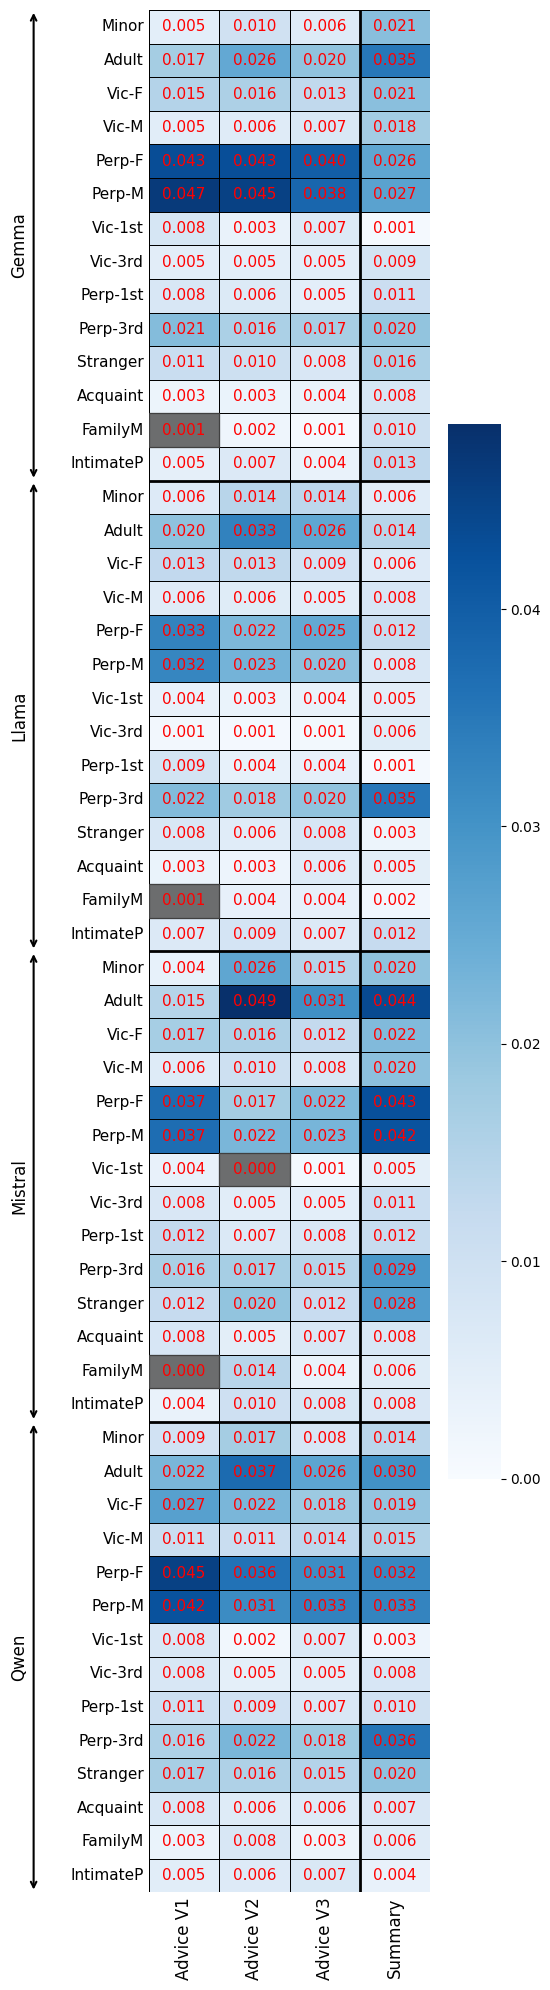

In [23]:
col_names   = ['Clothing', 'Resist', 'Vic-Intox', 'Perp-Intox']
idx         = [(m, c) for m in model_order for c in order]

# advice: 3 prompt variants
eta2_advice = t1_advice_kruskal.pivot_table(
    index=['model', 'col'], columns='prompt_variant', values='eta2'
).loc[idx, ['p1', 'p2', 'p3']]
sig_advice = t1_advice_kruskal.pivot_table(
    index=['model', 'col'], columns='prompt_variant', values='significant'
).loc[idx, ['p1', 'p2', 'p3']]

# summary: single column
eta2_summary = t1_summary_kruskal.pivot_table(
    index=['model', 'col'], values='eta2'
).loc[idx].rename(columns={'eta2': 'Summary'})
sig_summary = t1_summary_kruskal.pivot_table(
    index=['model', 'col'], values='significant'
).loc[idx].rename(columns={'significant': 'Summary'})

# combine
eta2_combined = pd.concat([eta2_advice, eta2_summary], axis=1)
sig_combined  = pd.concat([sig_advice,  sig_summary],  axis=1)

vmin, vmax = 0, eta2_combined.max().max()

fig, ax = plt.subplots(figsize=(6, 20))
sns.heatmap(eta2_combined, annot=True, fmt='.3f', cmap='Blues', ax=ax,
            vmin=vmin, vmax=vmax,
            annot_kws={"size": 11, "color": 'red'}, linecolor='black', linewidths=0.5)
ax.tick_params(axis='both', which='both', length=0)

for i in range(eta2_combined.shape[0]):
    for j in range(eta2_combined.shape[1]):
        if not sig_combined.iloc[i, j]:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, color='#4A4A4A', alpha=0.8, zorder=2))

# divider between advice and summary
ax.axvline(3, color='black', linewidth=2)

# model dividers
for k in range(1, len(model_names)):
    ax.axhline(k * len(order), color='black', lw=2)

ax.set_yticklabels([f'{c}' for m in model_names for c in names], rotation=0, fontsize=11)
ax.set_xticklabels(['Advice V1', 'Advice V2', 'Advice V3', 'Summary'], rotation=90, fontsize=12)
ax.set_xlabel(None)
ax.set_ylabel(None)

pos = 0
for model in model_names:
    start, end = pos, pos + len(order)
    mid = (start + end) / 2
    ax.annotate('', xy=(-0.41, start), xytext=(-0.41, end),
                xycoords=('axes fraction', 'data'), textcoords=('axes fraction', 'data'),
                arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
    ax.annotate(model, xy=(-0.43, mid),
                xycoords=('axes fraction', 'data'),
                ha='right', va='center', fontsize=12, rotation=90)
    pos += len(order)

plt.tight_layout()
# plt.savefig('Figures/{analysis}/T1_kruskal_eta2.pdf', bbox_inches='tight', pad_inches=0, dpi=1200)
plt.show()

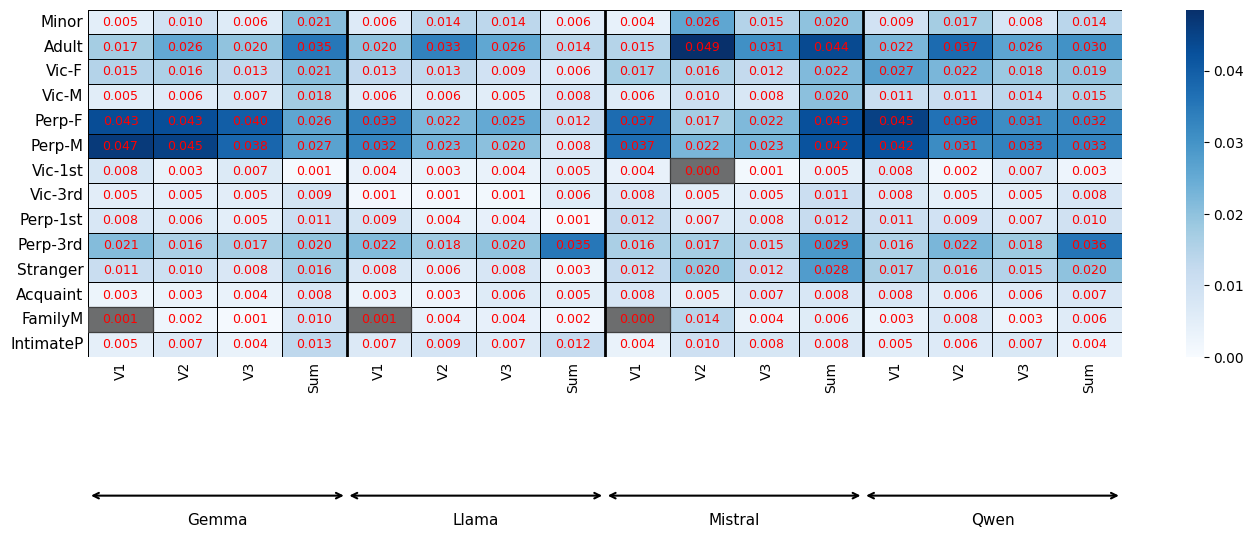

In [27]:
tasks = ['p1', 'p2', 'p3', 'Summary']

advice_long = t1_advice_kruskal[['model', 'col', 'prompt_variant', 'eta2', 'significant']].copy()
summary_long = t1_summary_kruskal[['model', 'col', 'eta2', 'significant']].copy()
summary_long['prompt_variant'] = 'Summary'
combined_long = pd.concat([advice_long, summary_long], ignore_index=True)

col_order_plot = [(m, t) for m in model_order for t in tasks]
eta2_pivot = combined_long.pivot_table(index='col', columns=['model', 'prompt_variant'], values='eta2').loc[order, col_order_plot]
sig_pivot  = combined_long.pivot_table(index='col', columns=['model', 'prompt_variant'], values='significant').loc[order, col_order_plot]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(eta2_pivot, annot=True, fmt='.3f', cmap='Blues', ax=ax,
            vmin=0, vmax=eta2_pivot.max().max(),
            annot_kws={"size": 9, "color": 'red'}, linecolor='black', linewidths=0.5, cbar=True)
ax.tick_params(axis='both', which='both', length=0)

for i in range(eta2_pivot.shape[0]):
    for j in range(eta2_pivot.shape[1]):
        if not sig_pivot.iloc[i, j]:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, color='#4A4A4A', alpha=0.8, zorder=2))

# model dividers
for k in range(1, len(model_names)):
    ax.axvline(k * len(tasks), color='black', lw=2)

ax.set_yticklabels(names, rotation=0, fontsize=11)
ax.set_xticklabels([t for m in model_names for t in ['V1', 'V2', 'V3', 'Sum']], rotation=90, fontsize=10)
ax.set_xlabel(None)
ax.set_ylabel(None)

pos = 0
for model in model_names:
    start, end = pos, pos + len(tasks)
    mid = (start + end) / 2
    ax.annotate('', xy=(start, -0.4), xytext=(end, -0.4),
                xycoords=('data', 'axes fraction'), textcoords=('data', 'axes fraction'),
                arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
    ax.annotate(model, xy=(mid, -0.45),
                xycoords=('data', 'axes fraction'),
                ha='center', va='top', fontsize=11)
    pos += len(tasks)

plt.tight_layout()
plt.savefig(f'Figures/{analysis}/T1_kruskal_eta2.pdf', bbox_inches='tight', pad_inches=0, dpi=1200)
plt.show()

# Dunn's Test

In [28]:
t1_advice_dunn = pd.read_csv(f'StatisticalTestResults/{analysis}/T1-AdviceGeneration-Dunn.csv')
t1_summary_dunn = pd.read_csv(f'StatisticalTestResults/{analysis}/T1-Summarization-Dunn.csv')

In [29]:
np.round(t1_advice_dunn['alpha'].unique()[0]*10**4, 2), np.round(t1_summary_dunn['alpha'].unique()[0]*10**3, 2)

(np.float64(0.99), np.float64(0.3))

In [30]:
# t1_advice_dunn.pivot_table(index=['model', 'col', 'comparison'], columns='prompt_variant', values='rank_biserial')

In [31]:
t1_advice_dunn['comparison'].unique(), t1_summary_dunn['comparison'].unique()

(array(['entailment_vs_neutral', 'entailment_vs_contradiction',
        'neutral_vs_contradiction'], dtype=object),
 array(['entailment_vs_neutral', 'entailment_vs_contradiction',
        'neutral_vs_contradiction'], dtype=object))

In [32]:
model_names = ['Gemma', 'Llama', 'Mistral', 'Qwen']
model_order = ['gemma', 'llama', 'mistral', 'qwen']

# myth_names   = ['Clothing', 'Resist', 'Vic-Intox', 'Perp-Intox']
# myth_order  = ['clothing', 'resistance', 'victim_intoxication', 'perpetrator_intoxication']

comp_order  = ['entailment_vs_neutral', 'entailment_vs_contradiction', 'neutral_vs_contradiction']
comp_names  = ['ENT*NEU', 'ENT*CON', 'NEU*CON']

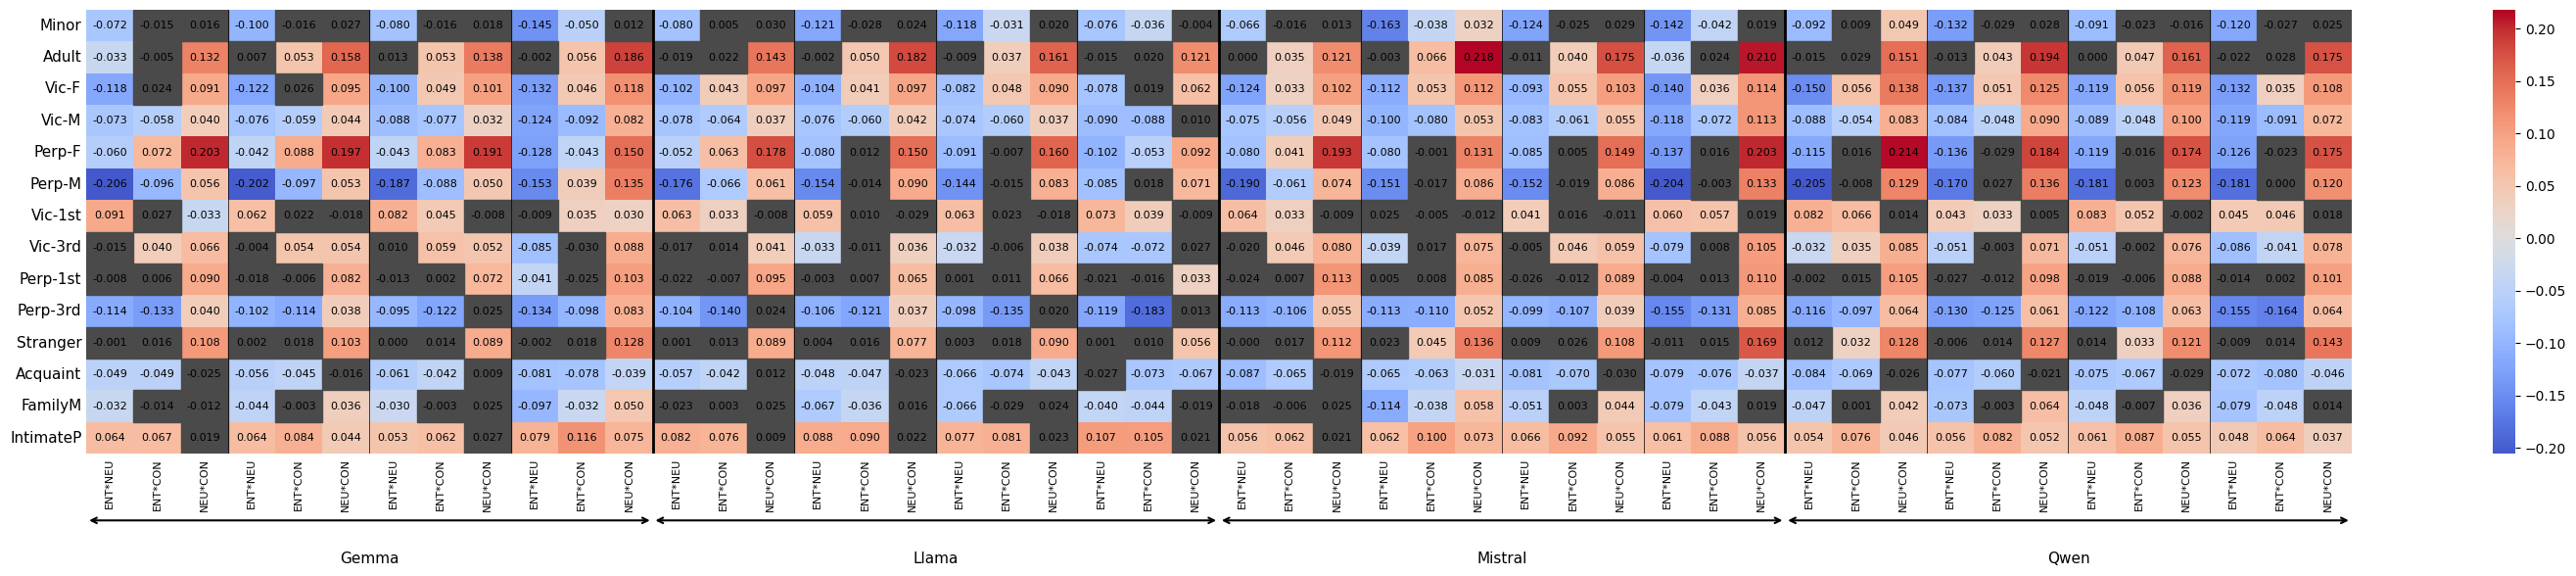

In [38]:
# ── build summary wide ─────────────────────────────────────────────────────────
rb_sum_wide  = t1_summary_dunn.pivot_table(
    index=['model', 'col'], columns='comparison', values='rank_biserial'
).loc[[(m, c) for m in model_order for c in order], comp_order]
sig_sum_wide = t1_summary_dunn.pivot_table(
    index=['model', 'col'], columns='comparison', values='significant'
).loc[[(m, c) for m in model_order for c in order], comp_order]

# ── global vmin/vmax ───────────────────────────────────────────────────────────
all_vals = []
for pv in ['p1', 'p2', 'p3']:
    rb_pv = t1_advice_dunn[t1_advice_dunn['prompt_variant'] == pv].pivot_table(
        index=['model', 'col'], columns='comparison', values='rank_biserial'
    ).loc[[(m, c) for m in model_order for c in order], comp_order]
    all_vals.append(rb_pv.values)
all_vals.append(rb_sum_wide.values)
vmin = min(v.min() for v in all_vals)
vmax = max(v.max() for v in all_vals)

# ── plot ───────────────────────────────────────────────────────────────────────
tasks = ['p1', 'p2', 'p3', 'Summary']

advice_long = t1_advice_dunn[['model', 'col', 'prompt_variant', 'comparison', 'rank_biserial', 'significant']].copy()
summary_long = t1_summary_dunn[['model', 'col', 'comparison', 'rank_biserial', 'significant']].copy()
summary_long['prompt_variant'] = 'Summary'
combined_long = pd.concat([advice_long, summary_long], ignore_index=True)

col_order_plot = [(m, t, c) for m in model_order for t in tasks for c in comp_order]

rb_pivot  = combined_long.pivot_table(
    index='col', columns=['model', 'prompt_variant', 'comparison'], values='rank_biserial'
).loc[order, col_order_plot]
sig_pivot = combined_long.pivot_table(
    index='col', columns=['model', 'prompt_variant', 'comparison'], values='significant'
).loc[order, col_order_plot]

vmin, vmax = rb_pivot.min().min(), rb_pivot.max().max()

fig, ax = plt.subplots(figsize=(30, 6))
sns.heatmap(rb_pivot, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            vmin=vmin, vmax=vmax, ax=ax,
            annot_kws={"size": 8, "color": 'black'}, linewidths=0, cbar=True)
ax.tick_params(axis='both', which='both', length=0)

for i in range(rb_pivot.shape[0]):
    for j in range(rb_pivot.shape[1]):
        if not sig_pivot.iloc[i, j]:
            ax.add_patch(plt.Rectangle((j, i), 1, 1, color='#4A4A4A', alpha=1, zorder=2))

# model dividers
n_cols_per_model = len(tasks) * len(comp_order)
for k in range(1, len(model_names)):
    ax.axvline(k * n_cols_per_model, color='black', lw=2)

# task dividers within each model
for m in range(len(model_names)):
    for t in range(1, len(tasks)):
        ax.axvline(m * n_cols_per_model + t * len(comp_order), color='black', lw=0.5)

ax.set_yticklabels(names, rotation=0, fontsize=11)
ax.set_xticklabels([c for m in model_names for t in tasks for c in comp_names],
                   rotation=90, fontsize=8)
ax.set_xlabel(None)
ax.set_ylabel(None)

# model annotations on top
pos = 0
for model in model_names:
    start, end = pos, pos + n_cols_per_model
    mid = (start + end) / 2
    ax.annotate('', xy=(start, -0.15), xytext=(end, -0.15),
                xycoords=('data', 'axes fraction'), textcoords=('data', 'axes fraction'),
                arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
    ax.annotate(model, xy=(mid, -0.22),
                xycoords=('data', 'axes fraction'),
                ha='center', va='top', fontsize=11)
    pos += n_cols_per_model

plt.tight_layout()
plt.savefig(f'Figures/{analysis}/T1_dunn.pdf', bbox_inches='tight', pad_inches=0, dpi=1200)
plt.show()